In [4]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [5]:
llm = ChatGroq(
    model = "llama-3.1-8b-instant"
)


In [6]:
result = llm.invoke("who are you ")

print(result.content)

I'm an artificial intelligence model known as a Large Language Model (LLM). My primary function is to process and generate human-like text based on the input I receive. I can answer questions, provide information on a wide range of topics, engage in conversation, and even create creative content like stories and dialogue.

I'm a machine learning model, which means I was trained on a massive dataset of text to learn patterns and relationships between words, phrases, and ideas. This training allows me to understand and generate text that's often indistinguishable from human-written content.

I don't have personal experiences, emotions, or consciousness like humans do. I exist solely to assist and provide information to those who interact with me. You can think of me as a highly advanced, knowledgeable, and helpful tool that's always ready to chat and answer your questions.

How can I help you today?


# First Graph

## step 1 Define The Schema

In [7]:
from typing import TypedDict , List

class graph_schema(TypedDict):
    name : str
    message:str

## step-2: Crete The Node Functions

In [33]:
def welcome(state:graph_schema) -> graph_schema:

    current_name = state['name']
    current_message = state['message']

    response = llm.invoke(f"my name is {current_name}.{current_message} ").content

    state['message'] = response

    return state




## step-3 state Graph


In [34]:
from langgraph.graph import StateGraph , START, END

graph = StateGraph(graph_schema)

In [35]:
graph .add_node("welcome", welcome)
graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

## STEP4 Compile graph 


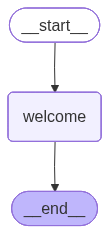

In [36]:
first_graph = graph.compile()
first_graph 

In [37]:
first_graph.invoke({"name" :"harry" , "message":"what is you name?"})

{'name': 'harry',
 'message': "Nice to meet you, Harry. I don't have a personal name, but I'm an AI designed to assist and communicate with users. You can think of me as a helpful assistant or a conversational partner. I don't have a personal identity, but I'm here to provide information, answer questions, and engage in conversation to the best of my abilities. How can I assist you today, Harry?"}